## Exploration

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re, pickle
import scipy
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression, RidgeCV , Ridge
from sklearn.metrics import mean_squared_error
from wordcloud import WordCloud, STOPWORDS
import scipy.sparse as sp
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor

trainingSet = pd.read_csv("./data/train.csv")
testingSet = pd.read_csv("./data/test.csv")

print("train.csv shape is ", trainingSet.shape)
print("test.csv shape is ", testingSet.shape)

print("Missing values in train:")
print(trainingSet.isnull().sum())
print()

df = trainingSet.copy()
print("df shape is ", df.shape)

train.csv shape is  (139753, 9)
test.csv shape is  (13976, 2)
Missing values in train:
Id                            0
ProductId                     0
UserId                        0
HelpfulnessNumerator          0
HelpfulnessDenominator        0
Time                          0
Summary                       1
Text                          1
Score                     13976
dtype: int64

df shape is  (139753, 9)


## Score Distribution

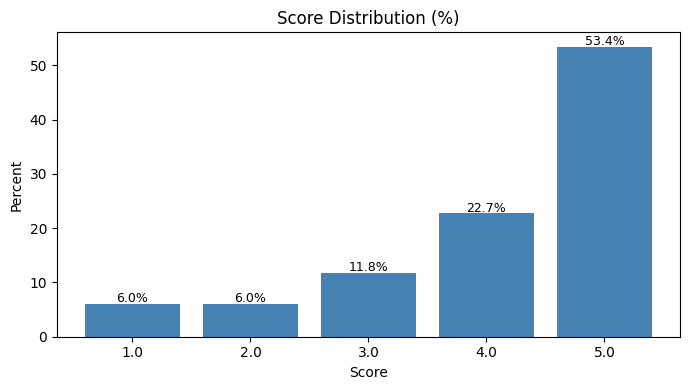

Class imbalance: 5-star vs 1-star: 8.8x


In [34]:
score_counts = df["Score"].value_counts().sort_index()
pct = score_counts / score_counts.sum() * 100

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(score_counts.index.astype(str), pct.values, color="steelblue")
ax.set_title("Score Distribution (%)")
ax.set_xlabel("Score")
ax.set_ylabel("Percent")
for bar, v in zip(bars, pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.3, f"{v:.1f}%", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig("./plots/score_distribution.png", bbox_inches="tight")
plt.show()

print(f"Class imbalance: 5-star vs 1-star: {score_counts[5.0] / score_counts[1.0]:.1f}x")


## User and product frequency 


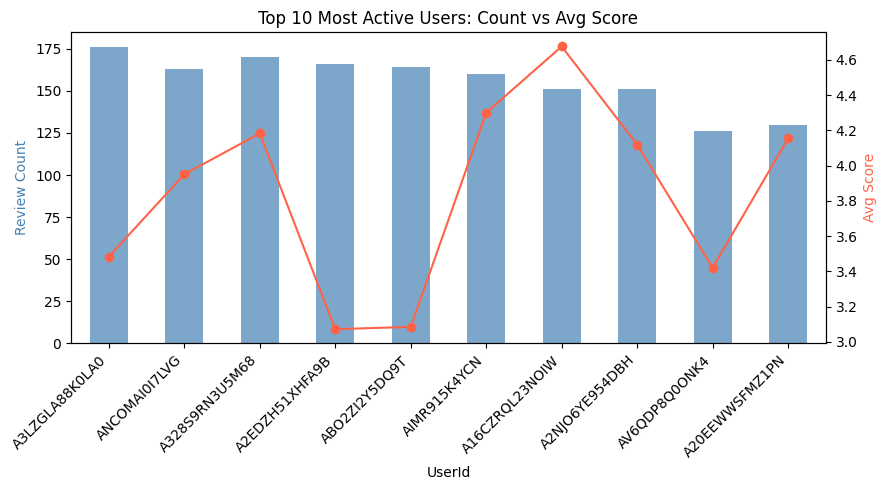

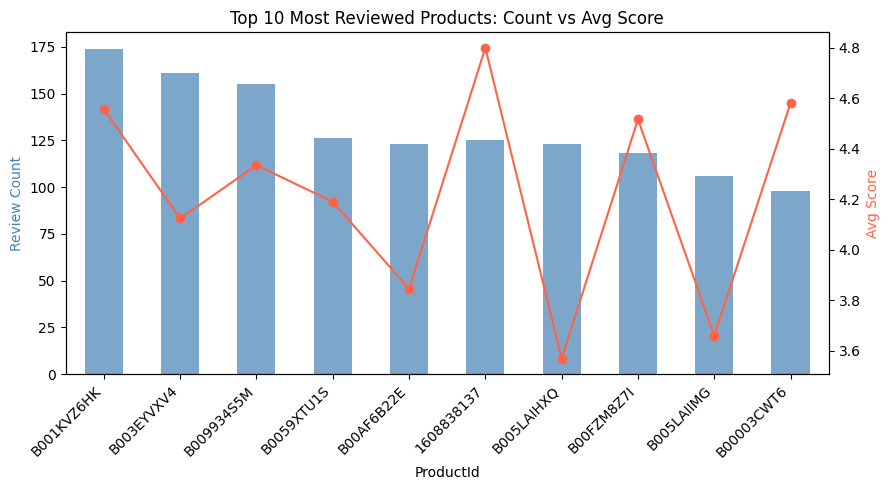

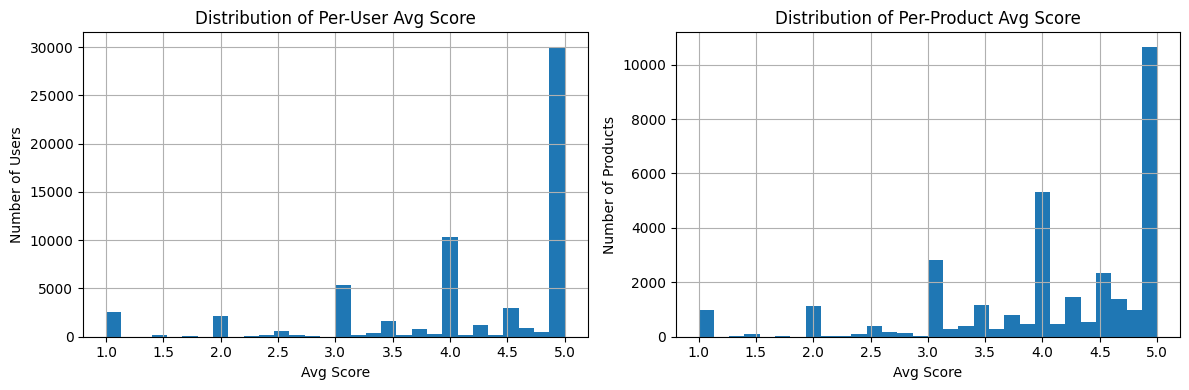

Unique users:    65269
Unique products: 34026
Users with only 1 review:    39296
Products with only 1 review: 13498
Users who always give 5 stars: 30003
Users who always give 1 star:  2567


In [35]:
# Top 10 users: review count + avg score side by side
top_user_ids = df["UserId"].value_counts().head(10).index
top_user_stats = df[df["UserId"].isin(top_user_ids)].groupby("UserId").agg(
    review_count=("Score", "count"),
    avg_score=("Score", "mean")
).loc[top_user_ids]

fig, ax1 = plt.subplots(figsize=(9, 5))
ax2 = ax1.twinx()
top_user_stats["review_count"].plot(kind="bar", ax=ax1, color="steelblue", alpha=0.7, label="Review Count")
ax2.plot(range(len(top_user_stats)), top_user_stats["avg_score"], color="tomato", marker="o", label="Avg Score")
ax1.set_title("Top 10 Most Active Users: Count vs Avg Score")
ax1.set_xlabel("UserId")
ax1.set_ylabel("Review Count", color="steelblue")
ax2.set_ylabel("Avg Score", color="tomato")
ax1.set_xticklabels(top_user_stats.index, rotation=45, ha="right")
plt.tight_layout()
plt.savefig("./plots/top_users_vs_score.png", bbox_inches="tight")
plt.show()

# Same for products
top_product_ids = df["ProductId"].value_counts().head(10).index
top_product_stats = df[df["ProductId"].isin(top_product_ids)].groupby("ProductId").agg(
    review_count=("Score", "count"),
    avg_score=("Score", "mean")
).loc[top_product_ids]

fig, ax1 = plt.subplots(figsize=(9, 5))
ax2 = ax1.twinx()
top_product_stats["review_count"].plot(kind="bar", ax=ax1, color="steelblue", alpha=0.7)
ax2.plot(range(len(top_product_stats)), top_product_stats["avg_score"], color="tomato", marker="o")
ax1.set_title("Top 10 Most Reviewed Products: Count vs Avg Score")
ax1.set_xlabel("ProductId")
ax1.set_ylabel("Review Count", color="steelblue")
ax2.set_ylabel("Avg Score", color="tomato")
ax1.set_xticklabels(top_product_stats.index, rotation=45, ha="right")
plt.tight_layout()
plt.savefig("./plots/top_products_vs_score.png", bbox_inches="tight")
plt.show()

# Bias distributions
user_avg = df.groupby("UserId")["Score"].mean()
product_avg = df.groupby("ProductId")["Score"].mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
user_avg.hist(bins=30, ax=axes[0])
axes[0].set_title("Distribution of Per-User Avg Score")
axes[0].set_xlabel("Avg Score")
axes[0].set_ylabel("Number of Users")

product_avg.hist(bins=30, ax=axes[1])
axes[1].set_title("Distribution of Per-Product Avg Score")
axes[1].set_xlabel("Avg Score")
axes[1].set_ylabel("Number of Products")

plt.tight_layout()
plt.savefig("./plots/bias_distributions.png", bbox_inches="tight")
plt.show()

# Sparsity check
user_counts    = df["UserId"].value_counts()
product_counts = df["ProductId"].value_counts()
print(f"Unique users:    {df['UserId'].nunique()}")
print(f"Unique products: {df['ProductId'].nunique()}")
print(f"Users with only 1 review:    {(user_counts == 1).sum()}")
print(f"Products with only 1 review: {(product_counts == 1).sum()}")
print(f"Users who always give 5 stars: {(user_avg == 5).sum()}")
print(f"Users who always give 1 star:  {(user_avg == 1).sum()}")

## Helpfulness

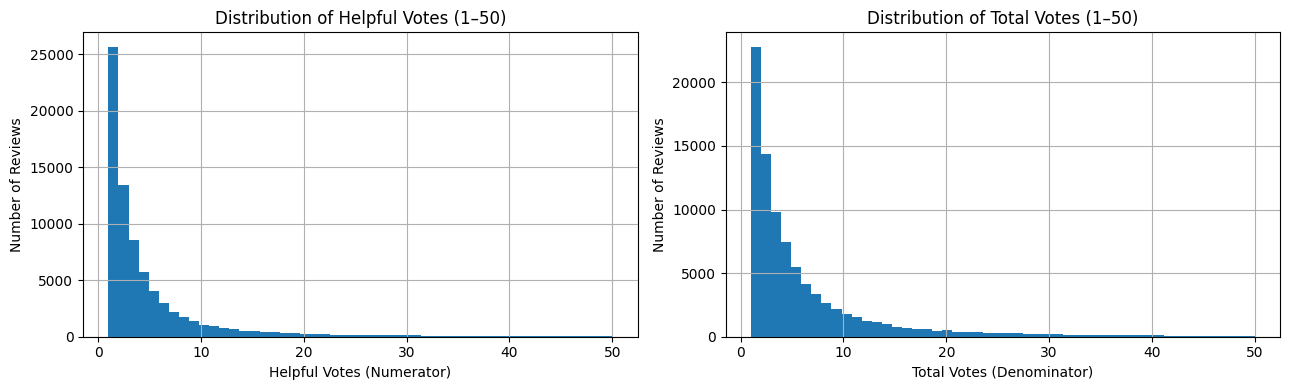

Numerator (Helpful Votes)
Reviews with 0 helpful votes : 45.8%
Reviews with 1 helpful vote  : 18.3%
Reviews with 5+ helpful votes: 16.0%

Denominator (Total Votes) 
Reviews with 0 votes : 35.8%
Reviews with 1 vote  : 16.3%
Reviews with 5+ votes: 25.2%

Among voted reviews, 100% helpful rate: 32.3%
df shape is  (139753, 9)


In [36]:
# Zoom in — cap at 50 to see the actual distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
df[df["HelpfulnessNumerator"].between(1, 50)]["HelpfulnessNumerator"].hist(bins=50, ax=axes[0])
axes[0].set_title("Distribution of Helpful Votes (1–50)")
axes[0].set_xlabel("Helpful Votes (Numerator)")
axes[0].set_ylabel("Number of Reviews")

df[df["HelpfulnessDenominator"].between(1, 50)]["HelpfulnessDenominator"].hist(bins=50, ax=axes[1])
axes[1].set_title("Distribution of Total Votes (1–50)")
axes[1].set_xlabel("Total Votes (Denominator)")
axes[1].set_ylabel("Number of Reviews")
plt.tight_layout()
plt.savefig("./plots/helpfulness_dist.png")
plt.show()

# Numerator breakdown
print("Numerator (Helpful Votes)")
print(f"Reviews with 0 helpful votes : {(df['HelpfulnessNumerator'] == 0).sum()/len(df):.1%}")
print(f"Reviews with 1 helpful vote  : {(df['HelpfulnessNumerator'] == 1).sum()/len(df):.1%}")
print(f"Reviews with 5+ helpful votes: {(df['HelpfulnessNumerator'] >= 5).sum()/len(df):.1%}")

# Denominator breakdown
print("\nDenominator (Total Votes) ")
print(f"Reviews with 0 votes : {(df['HelpfulnessDenominator'] == 0).sum()/len(df):.1%}")
print(f"Reviews with 1 vote  : {(df['HelpfulnessDenominator'] == 1).sum()/len(df):.1%}")
print(f"Reviews with 5+ votes: {(df['HelpfulnessDenominator'] >= 5).sum()/len(df):.1%}")

# How often numerator == denominator
perfect = (df["HelpfulnessNumerator"] == df["HelpfulnessDenominator"])
nonzero = (df["HelpfulnessDenominator"] > 0)
print(f"\nAmong voted reviews, 100% helpful rate: {(perfect & nonzero).sum()/nonzero.sum():.1%}")

print("df shape is ", df.shape)

## Time
Time can capture changes in user review behavior over years


Time range:
Earliest review: 1998-05-11 00:00:00
Latest review: 2014-07-23 00:00:00


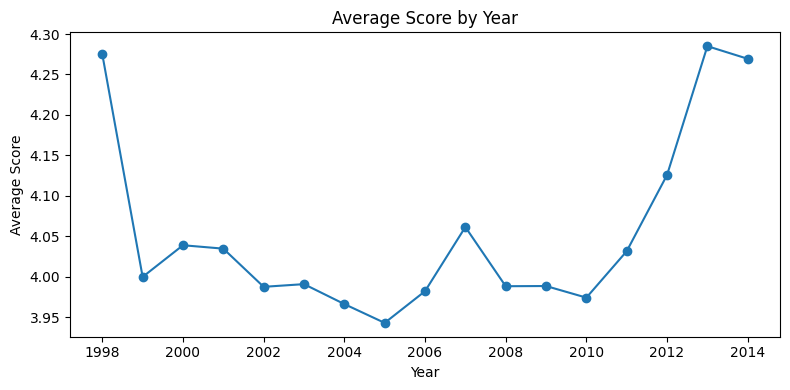

In [37]:
df["Time"] = pd.to_datetime(df["Time"], unit="s", errors="coerce")
df["year"]  = df["Time"].dt.year
df["month"] = df["Time"].dt.month


print("\nTime range:")
print("Earliest review:", df["Time"].min())
print("Latest review:", df["Time"].max())

# Average score over time 
avg_score_by_year = df.groupby("year")["Score"].mean()
plt.figure(figsize=(8, 4))
avg_score_by_year.plot(marker="o")
plt.title("Average Score by Year")
plt.xlabel("Year")
plt.ylabel("Average Score")
plt.tight_layout()
plt.savefig("./plots/avg_score_by_year.png", bbox_inches="tight")
plt.show()


## Text & Summary

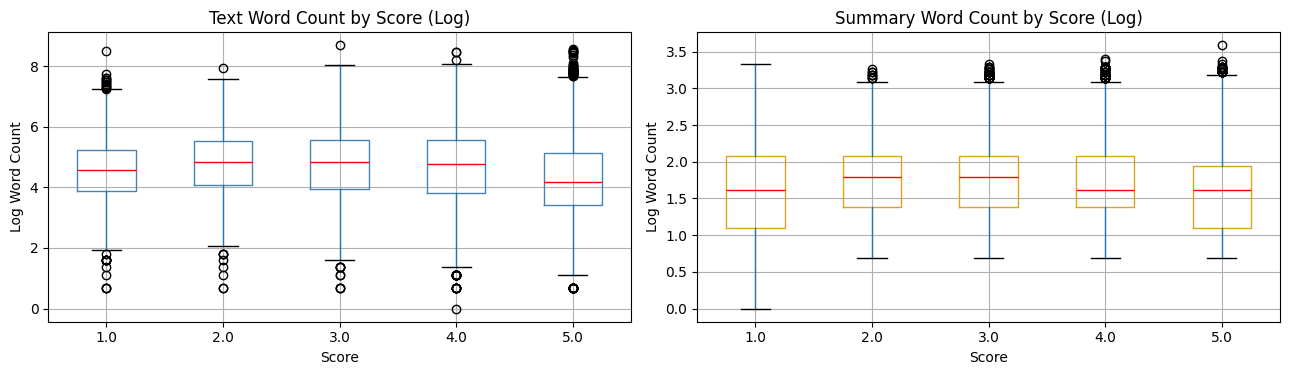

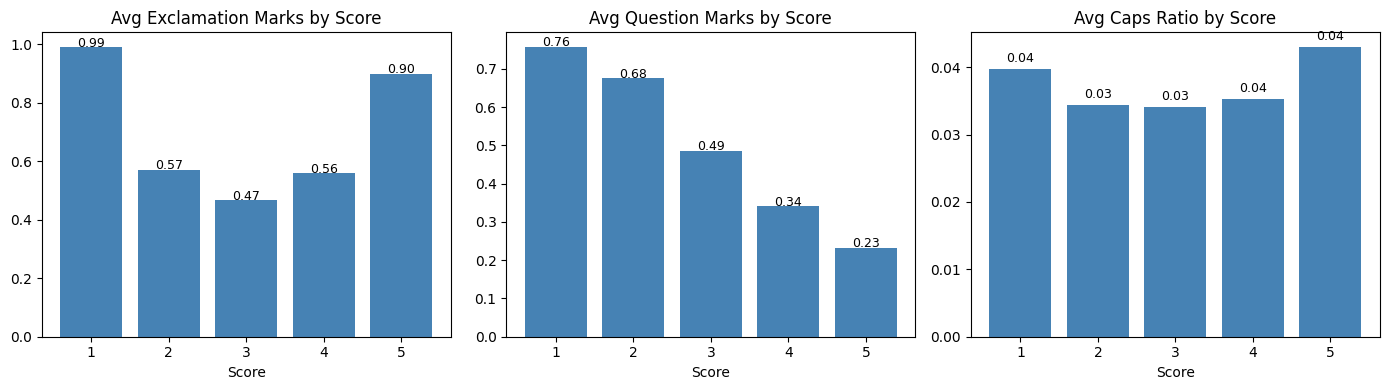

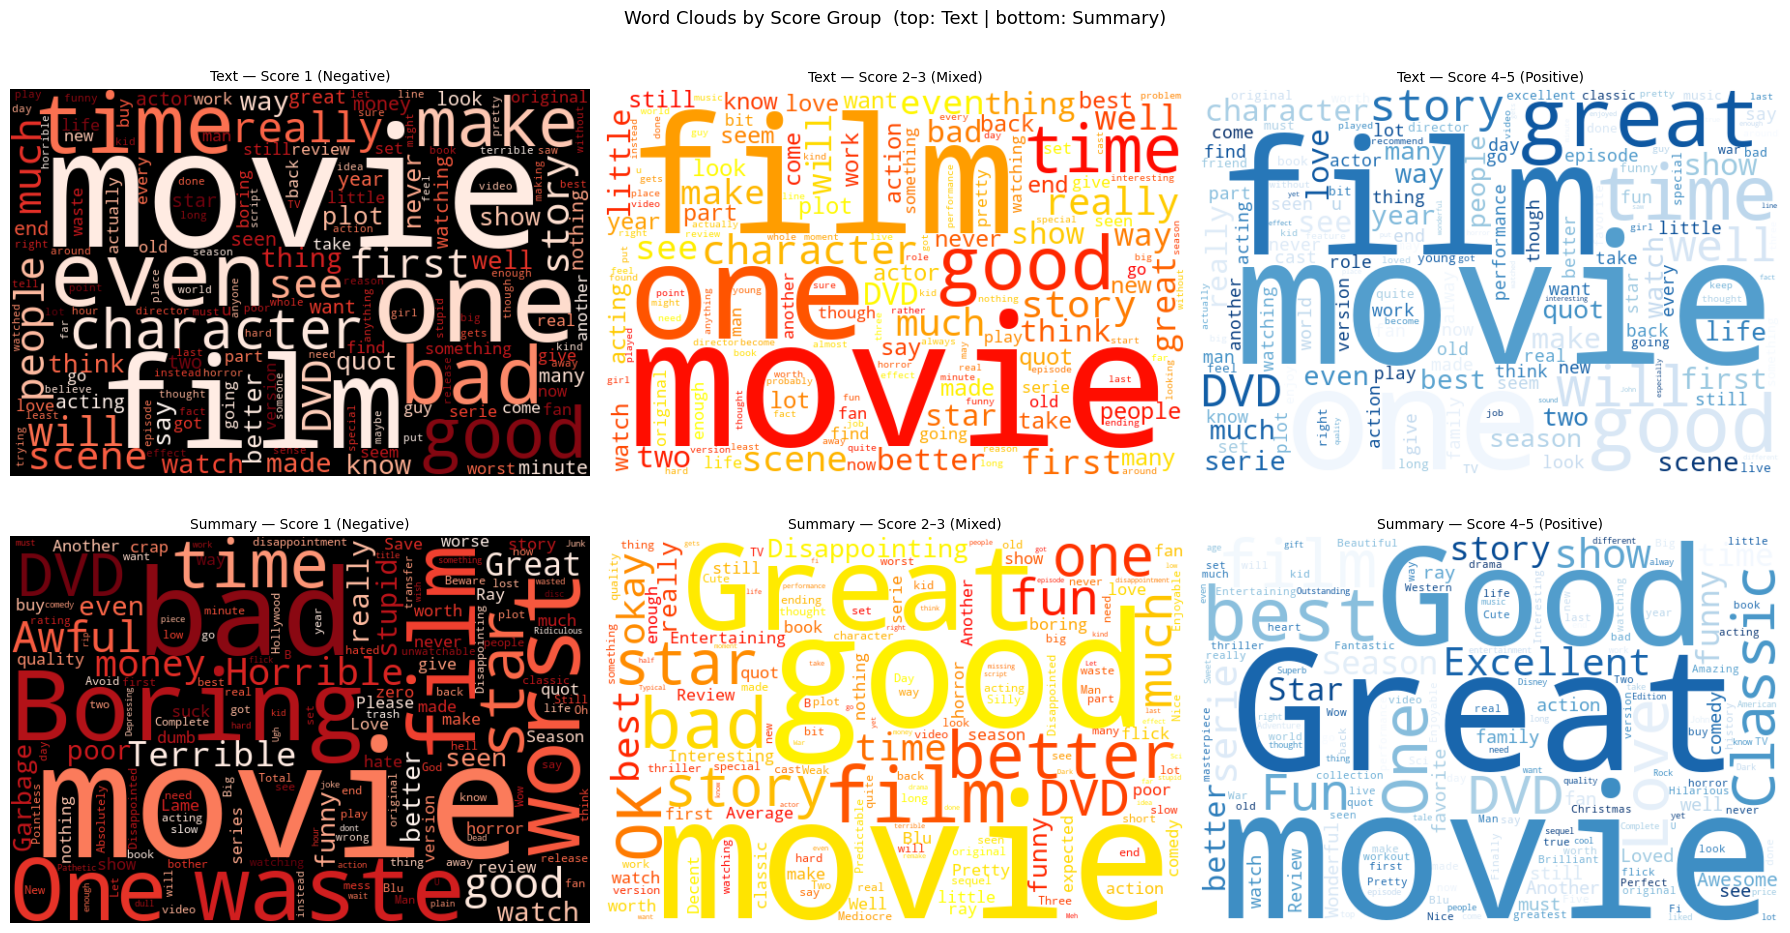

In [38]:
# Word Count vs Score (Log)
df["log_text_words"] = np.log1p(df["Text"].fillna("").astype(str).str.split().str.len())
df["log_summary_words"] = np.log1p(df["Summary"].fillna("").astype(str).str.split().str.len())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, col, title, color in zip(
    axes,
    ["log_text_words", "log_summary_words"],
    ["Text Word Count by Score (Log)", "Summary Word Count by Score (Log)"],
    ["steelblue", "goldenrod"]
):
    df.boxplot(column=col, by="Score", ax=ax,
               boxprops=dict(color=color),
               medianprops=dict(color="red"))
    ax.set_xlabel("Score")
    ax.set_ylabel("Log Word Count")
    plt.sca(ax); plt.title(title)
plt.suptitle("")
plt.tight_layout()
plt.savefig("./plots/length_vs_score.png", bbox_inches="tight")
plt.show()


# Writing Style
df["exclamation_count"] = df["Text"].fillna("").apply(lambda x: x.count("!"))
df["question_count"]    = df["Text"].fillna("").apply(lambda x: x.count("?"))
df["caps_ratio"]        = df["Text"].fillna("").apply(
    lambda x: sum(1 for c in x if c.isupper()) / (len(x) + 1)
)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col, title in zip(
    axes,
    ["exclamation_count", "question_count", "caps_ratio"],
    ["Avg Exclamation Marks by Score", "Avg Question Marks by Score", "Avg Caps Ratio by Score"]
):
    avg = df.groupby("Score")[col].mean()
    ax.bar(avg.index, avg.values, color="steelblue")
    ax.set_title(title)
    ax.set_xlabel("Score")
    for i, v in enumerate(avg.values):
        ax.text(i + 1, v + 0.001, f"{v:.2f}", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig("./plots/writing_style_by_score.png", bbox_inches="tight")
plt.show()

# Word Clouds
groups = {
    "Score 1 (Negative)":   df[df["Score"] == 1],
    "Score 2–3 (Mixed)":    df[df["Score"].isin([2, 3])],
    "Score 4–5 (Positive)": df[df["Score"].isin([4, 5])],
}
wc_settings = {
    "Score 1 (Negative)":   dict(background_color="black", colormap="Reds"),
    "Score 2–3 (Mixed)":    dict(background_color="white", colormap="autumn"),
    "Score 4–5 (Positive)": dict(background_color="white", colormap="Blues"),
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Word Clouds by Score Group  (top: Text | bottom: Summary)", fontsize=13)
for col, (label, grp) in enumerate(groups.items()):
    for row, field in enumerate(["Text", "Summary"]):
        text = " ".join(grp[field].fillna("").astype(str))
        wc = WordCloud(
            width=600, height=400,
            stopwords=STOPWORDS,
            max_words=150,
            collocations=False,
            **wc_settings[label]
        ).generate(text)
        axes[row, col].imshow(wc, interpolation="bilinear")
        axes[row, col].axis("off")
        axes[row, col].set_title(f"{'Text' if row == 0 else 'Summary'} — {label}", fontsize=10)
plt.tight_layout()
plt.savefig("./plots/wordclouds_by_score.png", bbox_inches="tight")
plt.show()

## Data Processing

Apply identical transformations to both train and test rows.

In [39]:
# Fill missing text fields
df["Text"]    = df["Text"].fillna("")
df["Summary"] = df["Summary"].fillna("")

# Fix helpfulness
df["HelpfulnessNumerator"]   = df["HelpfulnessNumerator"].fillna(0)
df["HelpfulnessDenominator"] = df["HelpfulnessDenominator"].fillna(0)

# Drop corrupted rows (numerator > denominator is impossible)
bad_mask = df["HelpfulnessNumerator"] > df["HelpfulnessDenominator"]
print(f"Corrupted helpfulness rows dropped: {bad_mask.sum()}")
df = df[~bad_mask].copy()

# Drop duplicates 
before = len(df)
df.drop_duplicates(subset=["UserId", "ProductId", "Text"], inplace=True)
print(f"Duplicate rows dropped: {before - len(df)}")

# Final check 
print(f"\nFinal df shape: {df.shape}")
print(f"\nRemaining nulls:\n{df.isnull().sum()[df.isnull().sum() > 0]}")

Corrupted helpfulness rows dropped: 1
Duplicate rows dropped: 0

Final df shape: (139752, 16)

Remaining nulls:
Score    13976
dtype: int64


## Spilt Train & Test & Vailation

In [40]:
from sklearn.model_selection import train_test_split

if "Score" not in trainingSet.columns:
    raise ValueError("train.csv must contain a Score column")

labeled_mask = trainingSet["Score"].notna()

df = trainingSet.loc[labeled_mask].copy()

# If unlabeled rows exist inside trainingSet, use them for prediction.
# Otherwise fall back to testingSet.
if (~labeled_mask).sum() > 0:
    predict_set = trainingSet.loc[~labeled_mask].copy()

    # if both sides have Id, align to testingSet order
    if "Id" in testingSet.columns and "Id" in predict_set.columns:
        predict_set = testingSet[["Id"]].merge(predict_set, on="Id", how="left")
else:
    predict_set = testingSet.copy()

print("Labeled rows   :", df.shape)
print("Prediction rows:", predict_set.shape)

# 2. Split labeled data only into train / validation
train_df, val_df = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    stratify=df["Score"].astype(int)
)

print("\nAfter validation split:")
print("train_df:", train_df.shape)
print("val_df  :", val_df.shape)

print("\nMissing values in train_df:")
print(train_df.isnull().sum())

print("\nMissing values in val_df:")
print(val_df.isnull().sum())

print("\nMissing values in predict_set:")
print(predict_set.isnull().sum())

Labeled rows   : (125777, 9)
Prediction rows: (13976, 9)

After validation split:
train_df: (100621, 9)
val_df  : (25156, 9)

Missing values in train_df:
Id                        0
ProductId                 0
UserId                    0
HelpfulnessNumerator      0
HelpfulnessDenominator    0
Time                      0
Summary                   1
Text                      0
Score                     0
dtype: int64

Missing values in val_df:
Id                        0
ProductId                 0
UserId                    0
HelpfulnessNumerator      0
HelpfulnessDenominator    0
Time                      0
Summary                   0
Text                      1
Score                     0
dtype: int64

Missing values in predict_set:
Id                            0
ProductId                     0
UserId                        0
HelpfulnessNumerator          0
HelpfulnessDenominator        0
Time                          0
Summary                       0
Text                          0
S

## Feature Engineering

Apply identical transformations to both train and test rows.


In [41]:
def safe_text(s):
    if pd.isna(s):
        return ""
    return str(s)

def add_count_features(train_like_df, apply_df, col):
    train_counts = train_like_df[col].fillna("MISSING").value_counts()
    out = apply_df[col].fillna("MISSING").map(train_counts).fillna(1)
    return np.log1p(out).astype(float)

def add_mean_target_features(train_df, apply_df, col, target="Score"):
    global_mean = train_df[target].mean()
    means = train_df.groupby(col)[target].mean()
    return apply_df[col].map(means).fillna(global_mean).astype(float)

def engineer_features(df, ref_df_for_counts):
    df = df.copy()
    df["Summary"] = df["Summary"].apply(safe_text)
    df["Text"]    = df["Text"].apply(safe_text)
    df["combined_text"] = (df["Summary"].str.strip() + " [SEP] " + df["Text"].str.strip()).str.strip()

    df["summary_char_count"]  = df["Summary"].str.len()
    df["text_char_count"]     = df["Text"].str.len()
    df["summary_word_count"]  = df["Summary"].str.split().str.len()
    df["text_word_count"]     = df["Text"].str.split().str.len()
    df["log_summary_chars"]   = np.log1p(df["summary_char_count"])
    df["log_text_chars"]      = np.log1p(df["text_char_count"])
    df["log_summary_words"]   = np.log1p(df["summary_word_count"])
    df["log_text_words"]      = np.log1p(df["text_word_count"])

    df["exclamation_count"]   = df["Text"].str.count("!")
    df["question_count"]      = df["Text"].str.count(r"\?")
    df["ellipsis_count"]      = df["Text"].str.count(r"\.\.\.")
    df["uppercase_ratio"]     = df["Text"].apply(lambda t: sum(c.isupper() for c in t) / max(len(t), 1))
    df["digit_ratio"]         = df["Text"].apply(lambda t: sum(c.isdigit() for c in t) / max(len(t), 1))

    for col in ["HelpfulnessNumerator", "HelpfulnessDenominator"]:
        df[col] = pd.to_numeric(df.get(col, 0), errors="coerce").fillna(0)
    df["helpfulness_ratio"]   = df["HelpfulnessNumerator"] / (df["HelpfulnessDenominator"] + 1.0)
    df["unhelpful_count"]     = (df["HelpfulnessDenominator"] - df["HelpfulnessNumerator"]).clip(lower=0)
    df["has_votes"]           = (df["HelpfulnessDenominator"] > 0).astype(int)
    df["log_help_num"]        = np.log1p(df["HelpfulnessNumerator"])
    df["log_help_den"]        = np.log1p(df["HelpfulnessDenominator"])

    if "Time" in df.columns:
        dt = pd.to_datetime(df["Time"], unit="s", errors="coerce")
        df["year"]      = dt.dt.year.fillna(2007)
        df["month"]     = dt.dt.month.fillna(0)
        df["dayofweek"] = dt.dt.dayofweek.fillna(0)
    else:
        df["year"] = 2007; df["month"] = 0; df["dayofweek"] = 0

    df["user_review_count_log"]    = add_count_features(ref_df_for_counts, df, "UserId")
    df["product_review_count_log"] = add_count_features(ref_df_for_counts, df, "ProductId")

    return df

train_df   = engineer_features(train_df, train_df)
val_df     = engineer_features(val_df, train_df)
predict_set = engineer_features(predict_set, train_df)

# User & Product bias features 
# def add_mean_target_features(train_df, apply_df, col, target="Score"):
#     global_mean = train_df[target].mean()
#     means = train_df.groupby(col)[target].mean()
#     return apply_df[col].map(means).fillna(global_mean).astype(float)

# train_df["user_avg_score"]    = add_mean_target_features(train_df, train_df, "UserId")
# val_df["user_avg_score"]      = add_mean_target_features(train_df, val_df,   "UserId")
# predict_set["user_avg_score"] = add_mean_target_features(train_df, predict_set, "UserId")

# train_df["product_avg_score"]    = add_mean_target_features(train_df, train_df, "ProductId")
# val_df["product_avg_score"]      = add_mean_target_features(train_df, val_df,   "ProductId")
# predict_set["product_avg_score"] = add_mean_target_features(train_df, predict_set, "ProductId")

def add_mean_target_features(train_df, apply_df, col, target="Score"):
    global_mean = train_df[target].mean()
    means = train_df.groupby(col)[target].mean()
    return apply_df[col].map(means).fillna(global_mean).astype(float)

def add_loo_mean_features(train_df, col, target="Score"):
    """Leave-one-out: exclude each row's own score from its average."""
    global_mean = train_df[target].mean()
    group_sum   = train_df.groupby(col)[target].transform("sum")
    group_count = train_df.groupby(col)[target].transform("count")
    loo = (group_sum - train_df[target]) / (group_count - 1)
    return loo.fillna(global_mean).astype(float)

# Train: leave-one-out (no self-inclusion)
train_df["user_avg_score"]    = add_loo_mean_features(train_df, "UserId")
train_df["product_avg_score"] = add_loo_mean_features(train_df, "ProductId")

# Val & predict: use full train means 
val_df["user_avg_score"]         = add_mean_target_features(train_df, val_df,      "UserId")
val_df["product_avg_score"]      = add_mean_target_features(train_df, val_df,      "ProductId")
predict_set["user_avg_score"]    = add_mean_target_features(train_df, predict_set, "UserId")
predict_set["product_avg_score"] = add_mean_target_features(train_df, predict_set, "ProductId")

# # ADD STD FEATURES HERE
# def add_std_features(train_df, apply_df, col, target="Score"):
#     global_std = train_df[target].std()
#     stds = train_df.groupby(col)[target].std()
#     return apply_df[col].map(stds).fillna(global_std).astype(float)

# train_df["user_score_std"]       = add_std_features(train_df, train_df,    "UserId")
# val_df["user_score_std"]         = add_std_features(train_df, val_df,      "UserId")
# predict_set["user_score_std"]    = add_std_features(train_df, predict_set, "UserId")

# train_df["product_score_std"]    = add_std_features(train_df, train_df,    "ProductId")
# val_df["product_score_std"]      = add_std_features(train_df, val_df,      "ProductId")
# predict_set["product_score_std"] = add_std_features(train_df, predict_set, "ProductId")


NUMERIC_COLS = [
    "summary_char_count", "text_char_count",
    "summary_word_count", "text_word_count",
    "log_summary_chars", "log_text_chars",
    "log_summary_words", "log_text_words",
    "exclamation_count", "question_count", "ellipsis_count",
    "uppercase_ratio", "digit_ratio",
    "HelpfulnessNumerator", "HelpfulnessDenominator",
    "helpfulness_ratio", "unhelpful_count", "has_votes",
    "log_help_num", "log_help_den",
    "year", "month", "dayofweek",
    "user_review_count_log", "product_review_count_log",
    "user_avg_score", "product_avg_score",
    # "user_score_std", "product_score_std", 
]

missing = [c for c in NUMERIC_COLS if c not in train_df.columns]
print("Missing columns:", missing)  
print("train_df:", train_df.shape)
print("val_df  :", val_df.shape)
print("val_df  :", predict_set.shape)

Missing columns: []
train_df: (100621, 35)
val_df  : (25156, 35)
val_df  : (13976, 35)


## TF-IDF
- **word TF-IDF** captures important words and short phrases
- **character TF-IDF** captures misspellings, fragments, punctuation style, and subword patterns
- **summary-only TF-IDF** gives the short summary extra importance
- **numeric features** preserve behavior and metadata signals

In [42]:
# 1. Stop words 
# custom_stop_words = list(set(ENGLISH_STOP_WORDS).union({
#     "movie", "movies","film", "one", "time", "story", "character",
#     "make", "watch", "people", "dvd", "see", "thing",
#     "really", "way", "good", "know", "will", "even",
#     "much", "like", "just", "get", "got", "go"
# }))

# 2. TF-IDF Vectorizers 

tfidf_word = TfidfVectorizer(
    lowercase=True,
    strip_accents="unicode",
    analyzer="word",
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.98,
    max_features=120000,    
    sublinear_tf=True,
    # stop_words=ENGLISH_STOP_WORDS,
)

tfidf_char = TfidfVectorizer(
    lowercase=True,
    strip_accents="unicode",
    analyzer="char_wb",
    ngram_range=(3, 5),
    min_df=3,
    max_features=60000,      
    sublinear_tf=True,
)

tfidf_summary = TfidfVectorizer(
    lowercase=True,
    strip_accents="unicode",
    analyzer="word",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.98,
    max_features=25000,  
    sublinear_tf=True,
    # stop_words=ENGLISH_STOP_WORDS,
)

# 3. TF-IDF (fit ONLY on train)

X_word_train = tfidf_word.fit_transform(train_df["combined_text"])
X_word_val   = tfidf_word.transform(val_df["combined_text"])
X_word_pred  = tfidf_word.transform(predict_set["combined_text"])

X_char_train = tfidf_char.fit_transform(train_df["combined_text"])
X_char_val   = tfidf_char.transform(val_df["combined_text"])
X_char_pred  = tfidf_char.transform(predict_set["combined_text"])

X_sum_train  = tfidf_summary.fit_transform(train_df["Summary"])
X_sum_val    = tfidf_summary.transform(val_df["Summary"])
X_sum_pred   = tfidf_summary.transform(predict_set["Summary"])

# 4. Numeric features (fit scaler ONLY on train)

scaler = StandardScaler()

X_num_train = sp.csr_matrix(
    scaler.fit_transform(train_df[NUMERIC_COLS].fillna(0))
)

X_num_val = sp.csr_matrix(
    scaler.transform(val_df[NUMERIC_COLS].fillna(0))
)

X_num_pred = sp.csr_matrix(
    scaler.transform(predict_set[NUMERIC_COLS].fillna(0))
)

# 5. Combine all features
X_train_all = sp.hstack(
    [X_word_train, X_char_train, X_sum_train, X_num_train],
    format="csr"
)

X_val_all = sp.hstack(
    [X_word_val, X_char_val, X_sum_val, X_num_val],
    format="csr"
)

X_pred_all = sp.hstack(
    [X_word_pred, X_char_pred, X_sum_pred, X_num_pred],
    format="csr"
)

# 6. Targets
y_train = train_df["Score"].astype(float).values
y_val   = val_df["Score"].astype(float).values

# 7. Sanity checks

print("X_train_all shape:", X_train_all.shape)
print("X_val_all shape:  ", X_val_all.shape)
print("X_pred_all shape: ", X_pred_all.shape)

print("\nScore distribution in train:")
print(pd.Series(y_train).value_counts().sort_index())

X_train_all shape: (100621, 205027)
X_val_all shape:   (25156, 205027)
X_pred_all shape:  (13976, 205027)

Score distribution in train:
1.0     6074
2.0     6054
3.0    11886
4.0    22857
5.0    53750
Name: count, dtype: int64


In [43]:
# ridge = Ridge(alpha=5)  
# ridge.fit(X_train_all, y_train)
# ridge_pred = np.clip(ridge.predict(X_val_all), 1.0, 5.0)
# ridge_rmse = np.sqrt(mean_squared_error(y_val, ridge_pred))
# print(f"RMSE of Ridge: {ridge_rmse:.4f}")

## Modeling Compare

In [44]:
results = []

# 1. KNN
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train_all, y_train)
knn_pred = np.clip(knn.predict(X_val_all), 1.0, 5.0)
knn_rmse = np.sqrt(mean_squared_error(y_val, knn_pred))
results.append(("KNN (k=5)", knn_rmse))
print(f"RMSE of KNN : {knn_rmse:.4f}")

# 2. Linear Regression
lin_reg = LinearRegression()
lin_reg.fit(X_train_all, y_train)

lin_pred = np.clip(lin_reg.predict(X_val_all), 1.0, 5.0)
lin_rmse = np.sqrt(mean_squared_error(y_val, lin_pred))
results.append(("Linear Regression", lin_rmse))
print(f"RMSE of Linear Regression : {lin_rmse:.4f}")


# 3.Ridge Regression
# ridge_alphas = [0.5, 1.0, 2.0, 5.0, 10.0]
# best_ridge_rmse = float("inf")
# best_ridge_alpha = None
# best_ridge_model = None

# for alpha in ridge_alphas:
#     ridge = Ridge(alpha=alpha)
#     ridge.fit(X_train_all, y_train)

#     ridge_pred = np.clip(ridge.predict(X_val_all), 1.0, 5.0)
#     ridge_rmse = np.sqrt(mean_squared_error(y_val, ridge_pred))

#     print(f"Ridge alpha={alpha:<4} -> RMSE = {ridge_rmse:.4f}")
#     results.append((f"Ridge (alpha={alpha})", ridge_rmse))

#     if ridge_rmse < best_ridge_rmse:
#         best_ridge_rmse = ridge_rmse
#         best_ridge_alpha = alpha
#         best_ridge_model = ridge

# print()
# print(f"Best Ridge alpha = {best_ridge_alpha}")
# print(f"Best Ridge RMSE  = {best_ridge_rmse:.4f}")

ridge = Ridge(alpha=5)
ridge.fit(X_train_all, y_train)
ridge_pred = np.clip(ridge.predict(X_val_all), 1.0, 5.0)
ridge_rmse = np.sqrt(mean_squared_error(y_val, ridge_pred))
results.append(("Ridge (alpha=5)", ridge_rmse))
print(f"RMSE of Ridge : {ridge_rmse:.4f}")


# 4. Logistic Regression
# log_C_values = [0.1, 0.5, 1.0, 2.0, 5.0]
# best_log_rmse = float("inf")
# best_log_C = None
# best_log_model = None

# for C in log_C_values:
#     log_reg = LogisticRegression(
#         C=C,
#         max_iter=2000,
#         solver="saga",
#         n_jobs=-1
#     )
#     log_reg.fit(X_train_all, y_train.astype(int))

#     classes = log_reg.classes_.astype(float)              # [1,2,3,4,5]
#     probs = log_reg.predict_proba(X_val_all)              # shape: (n_samples, n_classes)
#     log_pred = np.clip((probs * classes).sum(axis=1), 1.0, 5.0)

#     log_rmse = np.sqrt(mean_squared_error(y_val, log_pred))
#     print(f"Logistic Regression C={C:<4} -> RMSE = {log_rmse:.4f}")
#     results.append((f"Logistic Regression (C={C})", log_rmse))

#     if log_rmse < best_log_rmse:
#         best_log_rmse = log_rmse
#         best_log_C = C
#         best_log_model = log_reg

# print()
# print(f"Best Logistic C    = {best_log_C}")
# print(f"Best Logistic RMSE = {best_log_rmse:.4f}")

log_reg = LogisticRegression(C=1.0, max_iter=1000,solver="lbfgs")
log_reg.fit(X_train_all, y_train.astype(int))
classes  = log_reg.classes_.astype(float)
probs    = log_reg.predict_proba(X_val_all)
log_pred = np.clip((probs * classes).sum(axis=1), 1.0, 5.0)
log_rmse = np.sqrt(mean_squared_error(y_val, log_pred))
results.append(("Logistic Regression (C=1)", log_rmse))
print(f"RMSE of Logistic: {log_rmse:.4f}")

# Summary
print("\nModel Performance Comparison (lower RMSE is better):")
for name, rmse in sorted(results, key=lambda x: x[1]):
    print(f"  {name:<35} -> RMSE = {rmse:.4f}")

RMSE of KNN : 1.0428
RMSE of Linear Regression = 1.0118
RMSE of Ridge : 0.7076
RMSE of Logistic: 0.6599

Model Performance Comparison (lower RMSE is better):
  Logistic Regression (C=1)           -> RMSE = 0.6599
  Ridge (alpha=5)                     -> RMSE = 0.7076
  Linear Regression                   -> RMSE = 1.0118
  KNN (k=5)                           -> RMSE = 1.0428


## Train the Full data with Best Model

In [45]:
# Pick best model
best_name = min(results, key=lambda x: x[1])[0]
print(f"Best model: {best_name}")

if best_name == "Ridge (alpha=5)":
    final_model = Ridge(alpha=5)
elif best_name == "Logistic Regression (C=1)":
    final_model = LogisticRegression(C=1.0, max_iter=1000, solver="lbfgs")
elif best_name == "Linear Regression":
    final_model = LinearRegression()
else:
    final_model = KNeighborsRegressor(n_neighbors=5)

# Retrain on FULL data with score
X_full = sp.vstack([X_train_all, X_val_all])
y_full = np.concatenate([y_train, y_val])

final_model.fit(X_full, y_full.astype(int))
print(f"Retrained {best_name} on {X_full.shape[0]:,} rows")

# Sanity check
train_rmse = np.sqrt(mean_squared_error(y_full, np.clip(final_model.predict(X_full), 1.0, 5.0)))
print(f"Full train RMSE: {train_rmse:.4f}")

Best model: Logistic Regression (C=1)
Retrained Logistic Regression (C=1) on 125,777 rows
Full train RMSE: 0.4854


## Create Kaggle Submission

In [46]:
# Predict 
if best_name == "Logistic Regression (C=1)":
    classes     = final_model.classes_.astype(float)
    probs       = final_model.predict_proba(X_pred_all)
    final_preds = np.clip((probs * classes).sum(axis=1), 1.0, 5.0)
else:
    final_preds = np.clip(final_model.predict(X_pred_all), 1.0, 5.0)

predict_set["Score"] = final_preds

# Build submission
submission = predict_set[["Id", "Score"]].copy()
sample = pd.read_csv("./data/sample.csv")

# Validate IDs
missing_in_submission = set(sample["Id"]) - set(submission["Id"])
extra_in_submission   = set(submission["Id"]) - set(sample["Id"])
print(f"IDs in sample but missing: {len(missing_in_submission)}")
print(f"IDs extra in submission  : {len(extra_in_submission)}")
if not missing_in_submission and not extra_in_submission:
    print("All IDs match")

# Align to sample order
submission = sample[["Id"]].merge(submission, on="Id", how="left")
print(f"\nNull scores: {submission['Score'].isnull().sum()}")
print(f"Shape: {submission.shape}")
print(submission.head())
print("\nPrediction summary:")
print(submission["Score"].describe())

submission.to_csv("submission_last.csv", index=False)
print("\nsubmission_last.csv saved!")


# # Pick best model from results
# best_name = min(results, key=lambda x: x[1])[0]
# print(f"\nBest model: {best_name}")

# model_map = {
#     "KNN (k=5)":                knn,
#     "Linear Regression":        lin_reg,
#     "Logistic Regression (C=1)": log_reg,
#     "Ridge (alpha=5)":          ridge,
# }
# best_model = model_map[best_name]
# print(f"Using: {best_model}")

# final_preds = np.clip(best_model.predict(X_pred_all), 1.0, 5.0)
# predict_set["Score"] = final_preds

# # Build submission
# submission = predict_set[["Id", "Score"]].copy()

# # Validate against sample.csv
# sample = pd.read_csv("./data/sample.csv")

# # Check 1: any IDs in sample missing from submission
# missing_in_submission = set(sample["Id"]) - set(submission["Id"])
# # Check 2: any IDs in submission missing from sample
# extra_in_submission   = set(submission["Id"]) - set(sample["Id"])

# print(f"IDs in sample but missing from submission : {len(missing_in_submission)}")
# print(f"IDs in submission but not in sample       : {len(extra_in_submission)}")

# if missing_in_submission:
#     print(" Missing IDs:", list(missing_in_submission)[:10])
# if extra_in_submission:
#     print(" Extra IDs:  ", list(extra_in_submission)[:10])

# if not missing_in_submission and not extra_in_submission:
#     print(" All IDs match ")

# # Align order to match sample.csv
# submission = sample[["Id"]].merge(submission, on="Id", how="left")

# # Final check for any nulls after merge
# print(f"\nNull scores after merge: {submission['Score'].isnull().sum()}")
# print(f"Submission shape: {submission.shape}")

# # Save
# submission.to_csv("submission_best.csv", index=False)
# print("\nsubmission.csv saved!")

IDs in sample but missing: 0
IDs extra in submission  : 0
All IDs match

Null scores: 0
Shape: (13976, 2)
        Id     Score
0  1224650  4.295045
1  1019381  3.630571
2   504719  4.842243
3  1622425  4.450997
4   482286  4.835049

Prediction summary:
count    13976.000000
mean         4.124511
std          0.968906
min          1.000526
25%          3.747835
50%          4.487421
75%          4.860493
max          4.999767
Name: Score, dtype: float64

submission_last.csv saved!
